##Simple  Linear Regression

# Step 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Explanation: Import Libraries

This block imports the necessary Python libraries:
- `pandas` as `pd`: Used for data manipulation and analysis, especially with DataFrames.
- `numpy` as `np`: Used for numerical operations, especially with arrays.
- `matplotlib.pyplot` as `plt`: Used for creating static, interactive, and animated visualizations in Python.

# Step 2: Upload CSV File

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving placement.csv to placement.csv


### Explanation: Upload CSV File

This block handles the upload of the `placement.csv` file from your local machine to the Colab environment. The `files.upload()` function from `google.colab` prompts you to select and upload the file.

# Step 3: Read Dataset

In [ ]:
df = pd.read_csv('placement.csv')

### Explanation: Read Dataset

After uploading, this cell reads the `placement.csv` file into a pandas DataFrame named `df`. This DataFrame will store our data for analysis.

# Step 4: Display First 5 Rows

In [ ]:
print(df.head())

   cgpa  package
0  6.89     3.26
1  5.12     1.98
2  7.82     3.25
3  7.42     3.67
4  6.94     3.57


### Explanation: Display First 5 Rows

The `df.head()` function is used here to display the first 5 rows of the DataFrame. This gives a quick overview of the data structure and content, showing the `cgpa` and `package` columns.

# Step 5: Scatter Plot

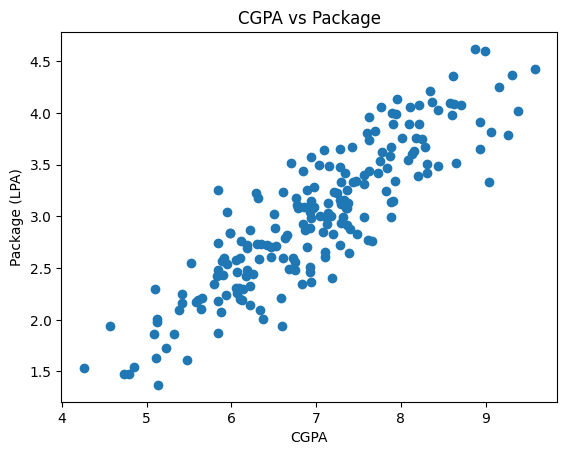

In [ ]:
plt.scatter(df['cgpa'], df['package'])
plt.xlabel("CGPA")
plt.ylabel("Package (LPA)")
plt.title("CGPA vs Package")
plt.show()

### Explanation: Scatter Plot

This block generates a scatter plot to visualize the relationship between `cgpa` and `package`.
- `plt.scatter(df['cgpa'], df['package'])`: Creates the scatter plot with `cgpa` on the x-axis and `package` on the y-axis.
- `plt.xlabel("CGPA")`, `plt.ylabel("Package (LPA)")`, `plt.title("CGPA vs Package")`: Set the labels for the axes and the title of the plot for clarity.
- `plt.show()`: Displays the generated plot.

# Step 6: Split Features and Target

In [ ]:
X = df[['cgpa']]
y = df['package']

### Explanation: Split Features and Target

In this step, we prepare our data for the linear regression model:
- `X = df[['cgpa']]`: The independent variable (feature) `X` is set to the 'cgpa' column. We use `[['cgpa']]` to ensure `X` is a DataFrame, which is typically required by scikit-learn models for a single feature.
- `y = df['package']`: The dependent variable (target) `y` is set to the 'package' column.

# Step 7: Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2
)

### Explanation: Train Test Split

This block splits the dataset into training and testing sets:
- `from sklearn.model_selection import train_test_split`: Imports the function for splitting data.
- `X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)`: Divides `X` and `y` into training (80%) and testing (20%) sets. `test_size=0.2` specifies that 20% of the data will be used for testing, and `random_state=2` ensures reproducibility of the split.

# Step 8: Import and Train Linear Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

### Explanation: Import and Train Linear Regression Model

Here, the linear regression model is initialized and trained:
- `from sklearn.linear_model import LinearRegression`: Imports the Linear Regression model class.
- `lr = LinearRegression()`: Creates an instance of the Linear Regression model.
- `lr.fit(X_train, y_train)`: Trains the model using the training data (`X_train` for features and `y_train` for target). The model learns the optimal slope and intercept during this step.

# Step 9: Predict Values

In [ ]:
y_pred = lr.predict(X_test)

### Explanation: Predict Values

This cell uses the trained linear regression model to make predictions on the test set:
- `y_pred = lr.predict(X_test)`: The `predict()` method takes the test features (`X_test`) and returns the predicted `package` values (`y_pred`).

# Step 10: Compare Actual vs Predicted

In [ ]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(comparison.head())

   Actual  Predicted
0    4.10   3.891116
1    3.49   3.093245
2    2.08   2.384646
3    2.33   2.574349
4    1.94   1.653729


### Explanation: Compare Actual vs Predicted

This block compares the actual `package` values from the test set with the predicted values:
- A new DataFrame `comparison` is created to hold both the actual and predicted values for easy comparison.
- `print(comparison.head())`: Displays the first few rows of this comparison DataFrame.

# Step 11: Predict for One Sample Input

In [ ]:
sample_prediction = lr.predict([[8.58]])

print("\nPredicted Package for CGPA 8.58:")
print(sample_prediction)


Predicted Package for CGPA 8.58:
[3.89111601]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Explanation: Predict for One Sample Input

This demonstrates how to use the trained model to predict the package for a new, single CGPA value:
- `sample_prediction = lr.predict([[8.58]])`: Predicts the package for a CGPA of 8.58. Note that the input `[[8.58]]` is a 2D array, which is the format expected by `predict()` for a single sample.
- The predicted value is then printed.

# Step 12: Plot Regression Line

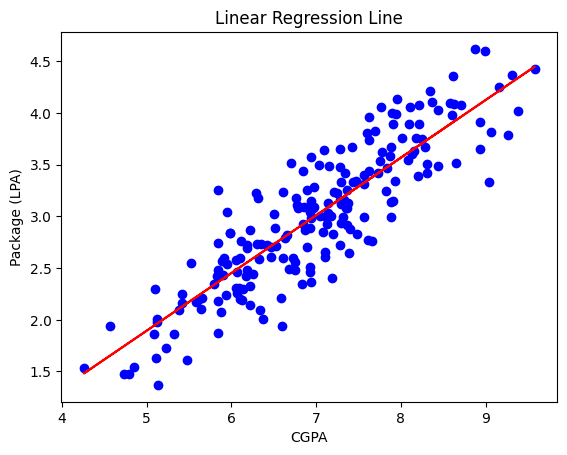

In [ ]:
plt.scatter(df['cgpa'], df['package'], color='blue')

plt.plot(
    X_train,
    lr.predict(X_train),
    color='red'
)

plt.xlabel("CGPA")
plt.ylabel("Package (LPA)")
plt.title("Linear Regression Line")
plt.show()

### Explanation: Plot Regression Line

This block visualizes the regression line along with the original scatter plot:
- `plt.scatter(df['cgpa'], df['package'], color='blue')`: Plots the original data points in blue.
- `plt.plot(X_train, lr.predict(X_train), color='red')`: Draws the linear regression line. It uses the training features (`X_train`) and the predictions made by the model on `X_train` to plot the line in red.
- Axes labels and title are set, and the plot is displayed.

# Step 13: Model Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation")
print("MAE :", mae)
print("MSE :", mse)
print("R2 Score :", r2)


Model Evaluation
MAE : 0.2884710931878175
MSE : 0.12129235313495527
R2 Score : 0.780730147510384


### Explanation: Model Evaluation

This step evaluates the performance of the linear regression model using common metrics:
- `from sklearn.metrics import ...`: Imports `mean_absolute_error`, `mean_squared_error`, and `r2_score`.
- `mae = mean_absolute_error(y_test, y_pred)`: Calculates the Mean Absolute Error, which is the average of the absolute differences between predictions and actual values.
- `mse = mean_squared_error(y_test, y_pred)`: Calculates the Mean Squared Error, which is the average of the squared differences between predictions and actual values. This penalizes larger errors more.
- `r2 = r2_score(y_test, y_pred)`: Calculates the R-squared score, which represents the proportion of the variance in the dependent variable that is predictable from the independent variable(s). A higher R-squared indicates a better fit.
- These evaluation metrics are then printed.

### Explanation of Evaluation Metrics Equations

These are the formulas for the evaluation metrics used:

1.  **Mean Absolute Error (MAE)**:

    $\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$

    Where:
    - $n$ is the number of data points.
    - $y_i$ is the actual value.
    - $\hat{y}_i$ is the predicted value.

    MAE measures the average magnitude of the errors in a set of predictions, without considering their direction. It's the average over the test sample of the absolute differences between prediction and actual observation where all individual differences have equal weight.

2.  **Mean Squared Error (MSE)**:

    $\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$

    Where:
    - $n$ is the number of data points.
    - $y_i$ is the actual value.
    - $\hat{y}_i$ is the predicted value.

    MSE measures the average of the squares of the errors. It's a common metric because it penalizes larger errors more heavily than MAE, making it sensitive to outliers.

3.  **R-squared (R2 Score)**:

    $$ \text{R}^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2} $$

    Where:
    - $n$ is the number of data points.
    - $y_i$ is the actual value.
    - $\hat{y}_i$ is the predicted value.
    - $\bar{y}$ is the mean of the actual values.

    The R-squared score, also known as the coefficient of determination, represents the proportion of the variance in the dependent variable that is predictable from the independent variable(s). It provides an indication of how well the model fits the observed data. An R2 score of 1 indicates a perfect fit, while a score of 0 suggests that the model explains none of the variability of the response data around its mean. A negative R2 score means the model is worse than simply predicting the mean of the target variable.

# Step 14: Coefficients

In [ ]:
print("\nSlope (m):", lr.coef_[0])
print("Intercept (b):", lr.intercept_)


Slope (m): 0.557951973425072
Intercept (b): -0.8961119222429144


### Explanation: Coefficients

Finally, this block prints the coefficients of the trained linear regression model:
- `lr.coef_[0]`: This is the slope (m) of the regression line, indicating how much the `package` is expected to change for a one-unit increase in `cgpa`.
- `lr.intercept_`: This is the intercept (b) of the regression line, which is the predicted `package` when `cgpa` is zero. In the context of CGPA, this might not have a direct real-world interpretation but is essential for the linear equation `y = mx + b`.

## LAB 3 : LINEAR REGRESSION

#### Step 1 : Import Libraries

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


#### Step 4 : Separate Input and Output

In [ ]:
X = df.iloc[:,0].values
y = df.iloc[:,1].values

print("X Values:")
print(X)

print("\nY Values:")
print(y)

X Values:
[6.89 5.12 7.82 7.42 6.94 7.89 6.73 6.75 6.09 8.31 5.32 6.61 8.94 6.93
 7.73 7.25 6.84 5.38 6.94 7.48 7.28 6.85 6.14 6.19 6.53 7.28 8.31 5.42
 5.94 7.15 7.36 8.1  6.96 6.35 7.34 6.87 5.99 5.9  8.62 7.43 9.38 6.89
 5.95 7.66 5.09 7.87 6.07 5.84 8.63 8.87 9.58 9.26 8.37 6.47 6.86 8.2
 5.84 6.6  6.92 7.56 5.61 5.48 6.34 9.16 7.36 7.6  5.11 6.51 7.56 7.3
 5.79 7.47 7.78 8.44 6.85 6.97 6.94 8.99 6.59 7.18 7.63 6.1  5.58 8.44
 4.26 4.79 7.61 8.09 4.73 6.42 7.11 6.22 7.9  6.79 5.83 6.63 7.11 5.98
 7.69 6.61 7.95 6.71 5.13 7.05 7.62 6.66 6.13 6.33 7.76 7.77 8.18 5.42
 8.58 6.94 5.84 8.35 9.04 7.12 7.4  7.39 5.23 6.5  5.12 5.1  6.06 7.33
 5.91 6.78 7.93 7.29 6.68 6.37 5.84 6.05 7.2  6.1  5.64 7.14 7.91 7.19
 7.91 6.76 6.93 4.85 6.17 5.84 6.07 5.66 7.57 8.28 6.3  6.12 7.37 7.94
 7.08 6.98 7.38 6.47 5.95 8.71 7.13 7.3  5.53 8.93 9.06 8.21 8.6  8.13
 8.65 9.31 6.22 8.01 6.93 6.75 7.32 7.04 6.29 7.09 8.15 7.14 6.19 8.22
 5.88 7.28 7.88 6.31 7.84 6.26 7.35 8.11 6.19 7.28 8.25 4.57 7.89 6.9

### Step 5 : Create Custom Linear Regression Class

In [ ]:
class LR:

    def __init__(self):
        self.m = None
        self.b = None

    def fit(self, X_train, y_train):

        num = 0
        den = 0

        for i in range(X_train.shape[0]):

            num = num + (
                (X_train[i] - X_train.mean()) *(y_train[i] - y_train.mean())
            )

            den = den + (
                (X_train[i] - X_train.mean()) * (X_train[i] - X_train.mean())
            )

        self.m = num / den

        self.b = y_train.mean() - (self.m * X_train.mean())

        print("Slope (m) =", self.m)
        print("Intercept (b) =", self.b)

    def predict(self, X_test):

        print("Input Value:", X_test)

        return self.m * X_test + self.b

### Step 6 : Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2
)

print("Shape of X_train:", X_train.shape)

Shape of X_train: (160,)


### Step 7 : Train Model

In [ ]:
lr = LR()

lr.fit(X_train, y_train)

Slope (m) = 0.5579519734250721
Intercept (b) = -0.8961119222429152


### Step 8 : Prediction

In [ ]:
pred = lr.predict(X_test[0])

print("\nPredicted Package:", pred)

Input Value: 8.58

Predicted Package: 3.891116009744203


### Step 9 : Manual Formula Verification

In [ ]:
print("\nVerification Values")
print("----------------------")

print("First X_train Value:", X_train[0])
print("Mean of X_train:", X_train.mean())
print("First X_test Value:", X_test[0])


Verification Values
----------------------
First X_train Value: 7.14
Mean of X_train: 6.989937500000001
First X_test Value: 8.58


### Step 10 : Plot Regression Line

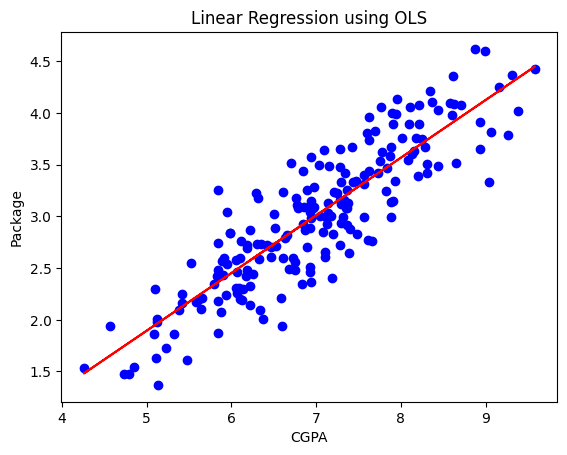

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X, y, color='blue')

# Regression Line
y_pred_line = lr.m * X + lr.b

plt.plot(X, y_pred_line, color='red')

plt.xlabel("CGPA")
plt.ylabel("Package")
plt.title("Linear Regression using OLS")

plt.show()

In [ ]:
# Save learned parameters into Pickle file

import pickle

parameters = {
    "slope": lr.m,
    "intercept": lr.b
}

with open("linear_regression_weights.pkl", "wb") as file:
    pickle.dump(parameters, file)

print("Parameters saved successfully")

Parameters saved successfully


## Multiple Linear Regression Example

### Step 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_regression
import plotly.express as px
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Explanation: Import Libraries

This block imports all the necessary Python libraries for performing multiple linear regression and visualization:
- `pandas` as `pd`: For data manipulation and creating DataFrames.
- `numpy` as `np`: For numerical operations, especially array manipulation.
- `sklearn.datasets.make_regression`: To generate a synthetic regression dataset.
- `plotly.express` as `px` and `plotly.graph_objects` as `go`: For interactive 3D visualizations.
- `sklearn.model_selection.train_test_split`: To split data into training and testing sets.
- `sklearn.linear_model.LinearRegression`: The linear regression model from scikit-learn.
- `sklearn.metrics` for `mean_absolute_error`, `mean_squared_error`, `r2_score`: To evaluate the model's performance.

### Step 2: Generate Synthetic Regression Dataset

In [ ]:
X, y = make_regression(
    n_samples=100,
    n_features=2,
    n_informative=2,
    n_targets=1,
    noise=50,
    random_state=42
)

df = pd.DataFrame({
    'feature1': X[:, 0],
    'feature2': X[:, 1],
    'target': y
})

### Explanation: Generate Synthetic Regression Dataset

This cell generates a synthetic dataset suitable for multiple linear regression:
- `make_regression`: Creates a random regression problem.
  - `n_samples=100`: Generates 100 data points.
  - `n_features=2`: Creates 2 features (independent variables).
  - `n_informative=2`: Both features are informative (contribute to the target).
  - `n_targets=1`: Generates a single target variable (dependent variable).
  - `noise=50`: Adds a significant amount of noise to the target variable.
  - `random_state=42`: Ensures reproducibility of the dataset.
- The generated features `X` and target `y` are then combined into a pandas DataFrame `df` with column names 'feature1', 'feature2', and 'target'.

### Step 3: Display DataFrame Information

In [ ]:
print(df.shape)
print(df.head())

(100, 3)
   feature1  feature2      target
0 -1.191303  0.656554  -22.779796
1  0.058209 -1.142970 -107.569629
2  0.586857  2.190456  201.122932
3  0.473238 -0.072829    1.480178
4  0.738467  0.171368  111.798503


### Explanation: Display DataFrame Information

This cell provides a quick overview of the generated DataFrame:
- `df.shape`: Prints the number of rows and columns in the DataFrame.
- `df.head()`: Displays the first 5 rows of the DataFrame, showing the structure and some sample data.

### Step 4: 3D Scatter Plot of the Data

In [ ]:
fig = px.scatter_3d(
    df,
    x='feature1',
    y='feature2',
    z='target',
    title='3D Scatter Plot'
)
fig.show()

### Explanation: 3D Scatter Plot

This cell generates an interactive 3D scatter plot using `plotly.express`:
- `px.scatter_3d`: Creates a 3D scatter plot.
  - `df`: The DataFrame containing the data.
  - `x='feature1'`, `y='feature2'`, `z='target'`: Specifies which columns map to the x, y, and z axes, respectively.
  - `title='3D Scatter Plot'`: Sets the title of the plot.
- `fig.show()`: Displays the interactive 3D plot, allowing you to rotate and zoom.

### Step 5: Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=3
)

### Explanation: Train-Test Split

This cell splits the dataset into training and testing sets:
- `train_test_split`: A function from `sklearn.model_selection` that randomly partitions the data.
  - `X`, `y`: The features and target arrays.
  - `test_size=0.2`: 20% of the data will be used for testing, and the remaining 80% for training.
  - `random_state=3`: Ensures that the split is reproducible, meaning you'll get the same split every time the code is run.

### Step 6: Train the Linear Regression Model

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

### Explanation: Train the Linear Regression Model

This cell initializes and trains the multiple linear regression model:
- `lr = LinearRegression()`: Creates an instance of the `LinearRegression` model.
- `lr.fit(X_train, y_train)`: Trains the model using the training data (`X_train` for features and `y_train` for the target). During this step, the model learns the optimal coefficients and intercept that best fit the training data.

### Step 7: Make Predictions

In [ ]:
y_pred = lr.predict(X_test)

### Explanation: Make Predictions

This cell uses the trained linear regression model to predict target values for the test dataset:
- `y_pred = lr.predict(X_test)`: The `predict()` method takes the test features (`X_test`) and returns the predicted target values (`y_pred`). These predictions can then be compared to the actual `y_test` values to evaluate the model's performance.

### Step 8: Evaluate Model Performance

In [ ]:
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("R2 Score :", r2_score(y_test, y_pred))

MAE : 47.0876578106196
MSE : 3639.6081061143386
R2 Score : 0.6551211257640548


### Explanation: Evaluate Model Performance

This cell calculates and prints common evaluation metrics to assess the trained model's performance on the test data:
- `mean_absolute_error(y_test, y_pred)`: Calculates the Mean Absolute Error (MAE), which is the average of the absolute differences between actual and predicted values. It gives a direct measure of the average magnitude of errors.
- `mean_squared_error(y_test, y_pred)`: Calculates the Mean Squared Error (MSE), which is the average of the squared differences. It penalizes larger errors more heavily.
- `r2_score(y_test, y_pred)`: Calculates the R-squared score (coefficient of determination), which indicates the proportion of the variance in the dependent variable that is predictable from the independent variables. A higher R2 score generally indicates a better fit (max value is 1).

### Step 9: Create Grid for Regression Plane

In [ ]:
x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)
xGrid, yGrid = np.meshgrid(x, y)
final = np.vstack((
    xGrid.ravel(),
    yGrid.ravel()
)).T
z_final = lr.predict(final).reshape(10, 10)

### Explanation: Create Grid for Regression Plane

This cell prepares the data needed to plot the 3D regression plane:
- `np.linspace(-5, 5, 10)`: Creates 10 evenly spaced points between -5 and 5 for both x and y axes.
- `np.meshgrid(x, y)`: Generates coordinate matrices from the coordinate vectors, creating a grid.
- `np.vstack(...).T`: Stacks the flattened x and y grid points vertically and then transposes, resulting in a 2D array where each row is a pair of (feature1, feature2) coordinates on the grid.
- `lr.predict(final).reshape(10, 10)`: Uses the trained model to predict the target (`z`) values for each point on the grid and reshapes them back into a 10x10 grid, representing the regression plane.

### Step 10: Plot 3D Scatter Plot with Regression Plane

In [ ]:
fig = px.scatter_3d(
    df,
    x='feature1',
    y='feature2',
    z='target',
    title='Multiple Linear Regression Plane'
)

fig.add_trace(
    go.Surface(
        x=xGrid,
        y=yGrid,
        z=z_final,
        opacity=0.5
    )
)

fig.show()

### Explanation: Plot 3D Scatter Plot with Regression Plane

This cell visualizes the original data points along with the fitted regression plane in 3D:
- `px.scatter_3d`: Creates the base scatter plot of the actual data points.
- `fig.add_trace(go.Surface(...))`: Adds a `go.Surface` trace to the existing scatter plot. This `Surface` represents the regression plane.
  - `x=x`, `y=y`, `z=z_final`: Uses the grid points and predicted z-values to define the surface.
  - `opacity=0.5`: Makes the surface semi-transparent so the underlying scatter points are still visible.
- `fig.show()`: Displays the combined interactive 3D plot, showing how the plane fits the data.

### Step 11: Display Model Parameters (Coefficients and Intercept)

In [ ]:
print("Coefficients :", lr.coef_)
print("Intercept :", lr.intercept_)

Coefficients : [81.05675748 72.39437821]
Intercept : 5.363809072090568


### Explanation: Display Model Parameters

This final cell prints the learned parameters of the linear regression model:
- `lr.coef_`: Displays the coefficients (slopes) for each feature. In multiple linear regression, there's a coefficient for each independent variable, indicating the change in the target for a one-unit change in that feature, holding other features constant.
- `lr.intercept_`: Displays the intercept, which is the predicted target value when all features are zero.

## Comprehensive Polynomial Regression Examples

### Part 1: Data Generation and Initial Visualization (1D Polynomial Data)

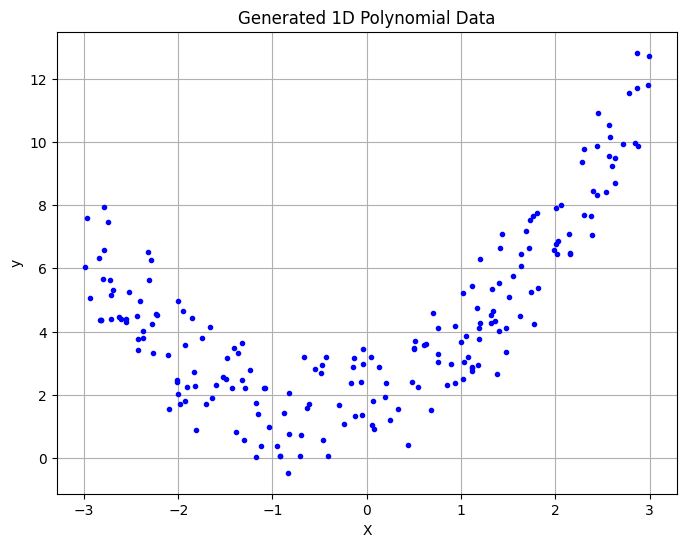

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

# Generate synthetic data following a quadratic pattern with noise
X_1d = 6 * np.random.rand(200, 1) - 3
y_1d = 0.8 * X_1d**2 + 0.9 * X_1d + 2 + np.random.randn(200, 1)

# Visualize the generated 1D data
plt.figure(figsize=(8, 6))
plt.plot(X_1d, y_1d, 'b.')
plt.xlabel("X")
plt.ylabel("y")
plt.title("Generated 1D Polynomial Data")
plt.grid(True)
plt.show()

This block imports all necessary libraries for various regression tasks and then generates a 1D synthetic dataset (`X_1d`, `y_1d`) with a quadratic relationship, simulating real-world data with added noise. A scatter plot visually confirms the non-linear pattern, indicating that a simple linear model would likely perform poorly.

### Part 2: Train-Test Split (for 1D Data)

In [ ]:
X_train_1d, X_test_1d, y_train_1d, y_test_1d = train_test_split(
    X_1d,
    y_1d,
    test_size=0.2,
    random_state=42
)

print(f"X_train_1d shape: {X_train_1d.shape}")
print(f"X_test_1d shape: {X_test_1d.shape}")

X_train_1d shape: (160, 1)
X_test_1d shape: (40, 1)


The generated 1D dataset is split into training (80%) and testing (20%) sets using `train_test_split`. `random_state=42` ensures reproducibility, meaning the same split will occur each time the code is run.

### Part 3: Simple Linear Regression (on 1D Polynomial Data)

R2 Score (Simple Linear Regression): 0.261


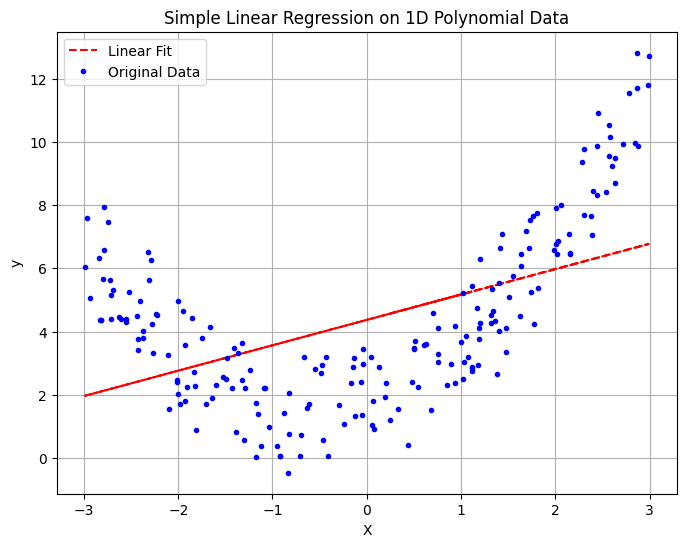

In [ ]:
lr_simple = LinearRegression()
lr_simple.fit(X_train_1d, y_train_1d)
y_pred_simple = lr_simple.predict(X_test_1d)

r2_simple = r2_score(y_test_1d, y_pred_simple)
print(f"R2 Score (Simple Linear Regression): {r2_simple:.3f}")

plt.figure(figsize=(8, 6))
plt.plot(X_train_1d, lr_simple.predict(X_train_1d), color='r', linestyle='--', label='Linear Fit')
plt.plot(X_1d, y_1d, "b.", label='Original Data')
plt.xlabel("X")
plt.ylabel("y")
plt.title("Simple Linear Regression on 1D Polynomial Data")
plt.legend()
plt.grid(True)
plt.show()

This section applies a standard `LinearRegression` model directly to the 1D polynomial data without any feature transformation. The low R2 score and the visual representation of a straight line attempting to fit a curve demonstrate the inadequacy of simple linear regression for non-linear relationships.

### Part 4: Polynomial Regression (Degree 2, 1D Data)

Original X_train_1d[0]: [0.24635393]
Transformed X_train_poly_2d[0]: [1.00000000e+00 2.46353931e-01 6.06902593e-02 1.49512839e-02
 3.68330757e-03 9.07397299e-04 2.23540892e-04 5.50701774e-05
 1.35667547e-05 3.34222334e-06 8.23369859e-07 2.02840401e-07
 4.99705302e-08 1.23104366e-08 3.03272444e-09 7.47123586e-10
 1.84056832e-10 4.53431242e-11 1.11704569e-11 2.75188596e-12
 6.77937925e-13 1.67012673e-13 4.11442284e-14 1.01360424e-14
 2.49705389e-15 6.15159042e-16 1.51546848e-16 3.73341618e-17
 9.19741751e-18 2.26581996e-18 5.58193653e-19 1.37513201e-19
 3.38769176e-20 8.34571181e-21 2.05599891e-21 5.06503414e-22
 1.24779107e-22 3.07398235e-23 7.57287636e-24 1.86560786e-24
 4.59599830e-25 1.13224225e-25 2.78932328e-26 6.87160756e-27
 1.69284753e-27 4.17039644e-28 1.02739356e-28 2.53102441e-29
 6.23527814e-30 1.53608528e-30 3.78420647e-31 9.32254139e-32
 2.29664472e-32 5.65787454e-33 1.39383963e-33 3.43377873e-34
 8.45924888e-35 2.08396922e-35 5.13394008e-36 1.26476632e-36
 3.11580155e-37 

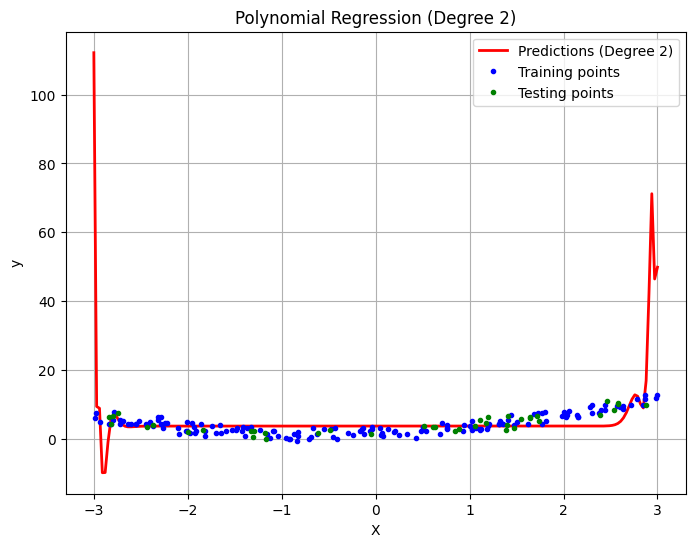

In [ ]:
poly_features_2d = PolynomialFeatures(degree=97, include_bias=True)

X_train_poly_2d = poly_features_2d.fit_transform(X_train_1d)
X_test_poly_2d = poly_features_2d.transform(X_test_1d)

print(f"Original X_train_1d[0]: {X_train_1d[0].flatten()}")
print(f"Transformed X_train_poly_2d[0]: {X_train_poly_2d[0].flatten()}")

lr_poly_2d = LinearRegression()
lr_poly_2d.fit(X_train_poly_2d, y_train_1d)
y_pred_poly_2d = lr_poly_2d.predict(X_test_poly_2d)

r2_poly_2d = r2_score(y_test_1d, y_pred_poly_2d)
print(f"\nPolynomial R2 Score (Degree 2): {r2_poly_2d:.3f}")
print(f"Coefficients (Degree 2): {lr_poly_2d.coef_.flatten()}")
print(f"Intercept (Degree 2): {lr_poly_2d.intercept_.flatten()}")

# Plotting the polynomial regression curve
X_new_1d = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly_2d = poly_features_2d.transform(X_new_1d)
y_new_pred_2d = lr_poly_2d.predict(X_new_poly_2d)

plt.figure(figsize=(8, 6))
plt.plot(X_new_1d, y_new_pred_2d, "r-", linewidth=2, label="Predictions (Degree 2)")
plt.plot(X_train_1d, y_train_1d, "b.", label='Training points')
plt.plot(X_test_1d, y_test_1d, "g.", label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.title("Polynomial Regression (Degree 2)")
plt.legend()
plt.grid(True)
plt.show()

Here, `PolynomialFeatures(degree=2)` transforms the single input feature `X_1d` into `[1, X, X^2]`. A `LinearRegression` model is then fitted to these transformed features. The significantly improved R2 score and the curved regression line on the plot demonstrate that polynomial transformation allows a linear model to capture non-linear patterns effectively. The coefficients and intercept for the polynomial equation are also displayed.

### Part 5: Polynomial Regression with Pipeline (1D Data)

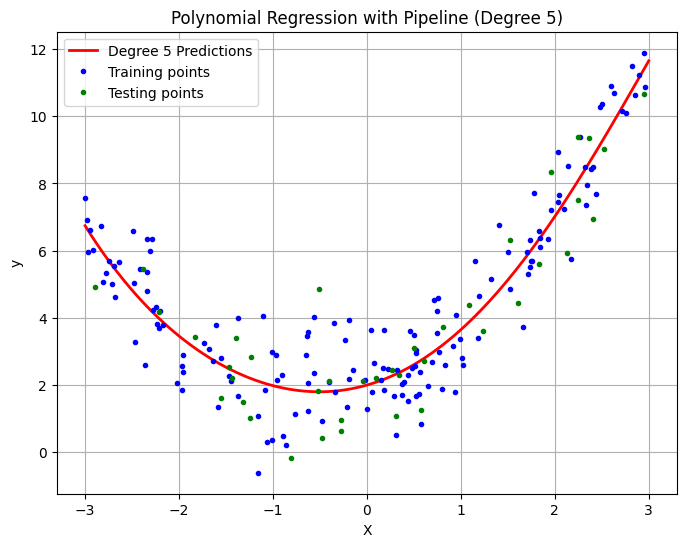

In [ ]:
def plot_polynomial_regression_pipeline(degree):
    polynomial_regression_pipeline = Pipeline([
        ("poly_features", PolynomialFeatures(degree=degree, include_bias=False)),
        ("std_scaler", StandardScaler()),
        ("lin_reg", LinearRegression()),
    ])

    polynomial_regression_pipeline.fit(X_1d, y_1d)

    X_new_1d_pipeline = np.linspace(-3, 3, 200).reshape(200, 1)
    y_new_pred_pipeline = polynomial_regression_pipeline.predict(X_new_1d_pipeline)

    plt.figure(figsize=(8, 6))
    plt.plot(
        X_new_1d_pipeline,
        y_new_pred_pipeline,
        'r',
        label=f"Degree {degree} Predictions",
        linewidth=2
    )

    plt.plot(X_train_1d, y_train_1d, "b.", label='Training points')
    plt.plot(X_test_1d, y_test_1d, "g.", label='Testing points')

    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.title(f"Polynomial Regression with Pipeline (Degree {degree})")
    plt.grid(True)
    plt.show()

plot_polynomial_regression_pipeline(5)

This segment introduces `Pipeline` for a streamlined workflow, combining `PolynomialFeatures`, `StandardScaler` (for feature scaling, often crucial for model stability), and `LinearRegression`. The `plot_polynomial_regression_pipeline` function demonstrates fitting a 5th-degree polynomial. Pipelines simplify complex machine learning workflows and prevent data leakage.

### Part 6: Gradient Descent Polynomial Regression (1D Data)

R2 Score (Gradient Descent Polynomial Regression): 0.852


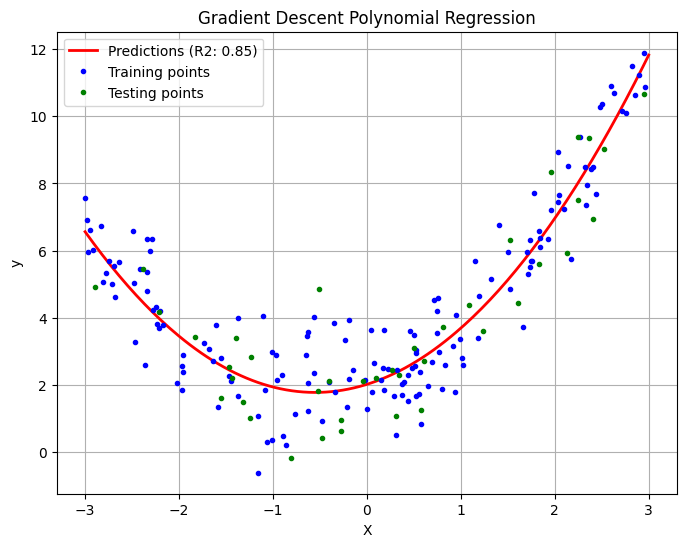

In [ ]:
poly_features_sgd = PolynomialFeatures(degree=2, include_bias=True)
X_train_poly_sgd = poly_features_sgd.fit_transform(X_train_1d)
X_test_poly_sgd = poly_features_sgd.transform(X_test_1d)

sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42, eta0=0.01)
sgd_reg.fit(X_train_poly_sgd, y_train_1d.ravel())

y_pred_sgd = sgd_reg.predict(X_test_poly_sgd)
r2_sgd = r2_score(y_test_1d, y_pred_sgd)
print(f"R2 Score (Gradient Descent Polynomial Regression): {r2_sgd:.3f}")

X_new_1d_sgd = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly_sgd = poly_features_sgd.transform(X_new_1d_sgd)
y_new_pred_sgd = sgd_reg.predict(X_new_poly_sgd)

plt.figure(figsize=(8, 6))
plt.plot(
    X_new_1d_sgd,
    y_new_pred_sgd,
    "r-",
    linewidth=2,
    label=f"Predictions (R2: {r2_sgd:.2f})"
)

plt.plot(X_train_1d, y_train_1d, "b.", label='Training points')
plt.plot(X_test_1d, y_test_1d, "g.", label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.title("Gradient Descent Polynomial Regression")
plt.legend()
plt.grid(True)
plt.show()

This section demonstrates polynomial regression using `SGDRegressor` (Stochastic Gradient Descent). After transforming features to a 2nd degree, the `SGDRegressor` iteratively optimizes the model parameters. This shows an alternative optimization algorithm compared to the analytical solution used by `LinearRegression`. The R2 score and plot confirm a similar good fit to the previous polynomial regression example.

### Part 7: 3D Polynomial Regression

In [ ]:
import plotly.express as px
import plotly.graph_objects as go

# Generate 3D data with a quadratic relationship
x_3d = 7 * np.random.rand(100, 1) - 2.8
y_3d = 7 * np.random.rand(100, 1) - 2.8
z_3d = (x_3d**2 + y_3d**2 + 0.2*x_3d + 0.2*y_3d + 0.1*x_3d*y_3d + 2 + np.random.randn(100, 1))

# Combine features for polynomial transformation
X_multi_3d = np.hstack((x_3d, y_3d))

# Apply Polynomial Features transformation (degree 2 for 3D surface)
poly_features_3d = PolynomialFeatures(degree=2, include_bias=True)
X_multi_trans_3d = poly_features_3d.fit_transform(X_multi_3d)

print(f"Shape of X_multi_3d: {X_multi_3d.shape}")
print(f"Number of input features: {poly_features_3d.n_features_in_}")
print(f"Number of output features (after transformation): {X_multi_trans_3d.shape[1]}")
print("Powers:\n", poly_features_3d.powers_)

# Train Linear Regression model on transformed features
lr_3d = LinearRegression()
lr_3d.fit(X_multi_trans_3d, z_3d)

# Create a grid for plotting the regression surface
x_input_3d = np.linspace(x_3d.min(), x_3d.max(), 20)
y_input_3d = np.linspace(y_3d.min(), y_3d.max(), 20)
xGrid_3d, yGrid_3d = np.meshgrid(x_input_3d, y_input_3d)

# Prepare and transform grid points for prediction
final_grid_3d = np.vstack((xGrid_3d.ravel(), yGrid_3d.ravel())).T
final_poly_3d = poly_features_3d.transform(final_grid_3d)

# Predict z-values for the surface
z_final_3d = lr_3d.predict(final_poly_3d).reshape(xGrid_3d.shape)

# Plot the 3D scatter plot with the regression surface
fig = px.scatter_3d(
    x=x_3d.ravel(),
    y=y_3d.ravel(),
    z=z_3d.ravel(),
    title='3D Polynomial Regression Surface'
)

fig.add_trace(
    go.Surface(
        x=x_input_3d,
        y=y_input_3d,
        z=z_final_3d,
        opacity=0.7,
        name='Regression Surface'
    )
)

fig.update_layout(
    scene=dict(
        zaxis=dict(range=[0, 35]) # Adjust z-axis range for better visualization
    )
)

fig.show()

Shape of X_multi_3d: (100, 2)
Number of input features: 2
Number of output features (after transformation): 6
Powers:
 [[0 0]
 [1 0]
 [0 1]
 [2 0]
 [1 1]
 [0 2]]


This final section extends polynomial regression to three dimensions. It generates 3D data (`x_3d`, `y_3d`, `z_3d`) with a quadratic relationship, including an interaction term (`x*y`). `PolynomialFeatures(degree=2)` creates terms like $x^2, y^2, xy$. A `LinearRegression` model is then fitted to predict `z` based on these transformed 3D features, effectively learning a curved surface. The `plotly` library is used to create an interactive 3D visualization, showing the original data points and the fitted polynomial regression surface.